In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat



probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y
probe_position['chan_map'] = probe_data['chanMap0ind'].astype(int)

chan_map = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
merged = chan_map.merge(probe_position, left_on='probeloc', right_on='chan_map')\
                 .iloc[chan_map.index]\
                 .reset_index(drop=True)

probe = Probe()
probe.set_contacts(positions=merged.iloc[:, 2:4])
probe.set_device_channel_indices(range(256))

In [2]:
recording_raw = se.read_intan(f"/home/ubuntu/Documents/jct/project/251205/M190011_251205_125223_merged_130.rhd", stream_id= '0', ignore_integrity_checks=True)

print('read success')

recording_raw = spre.unsigned_to_signed(recording_raw)
#recording_raw = spre.resample(recording_raw, 10000)

# recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
# recording_recorded = spre.notch_filter(recording_recorded, freq=50)
# recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

# recording_f = recording_f.set_probegroup(probe)

read success


In [3]:
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

In [4]:
recording_drift, motion, motion_info = spre.correct_motion(recording_f, preset='dredge', folder = '/home/ubuntu/Documents/jct/project/251205/drift/', 
                                                           output_motion=True, output_motion_info=True, n_jobs = 10, progress_bar = True)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 10 processes):   0%|          | 0/11311 [00:00<?, ?it/s]

Cross correlation:   0%|          | 0/25 [00:00<?, ?it/s]

Solve:   0%|          | 0/24 [00:00<?, ?it/s]

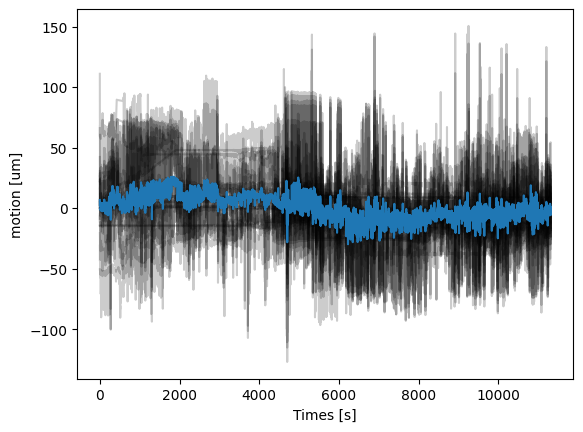

In [6]:
sw.plot_motion(motion)